# 1.Importing the Library

In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from IPython.display import Image,display

# 2.Defining the State

In [2]:
class bmi_state(TypedDict):
    height_m:float
    weight_kg:float
    bmi:float

# 3.Defining Node

In [3]:
def bmi_node(state:bmi_state):
    height=state["height_m"]
    weight=state["weight_kg"]
    bmi=weight/height**2
    return {
        "bmi_cal":bmi
    }

# 4.Adding Node and Edges

In [4]:
graph=StateGraph(bmi_state)
# Adding Node
graph.add_node("bmi_node",bmi_node)
# Adding Edge
graph.add_edge(START,"bmi_node")
graph.add_edge("bmi_node",END)

# 5.Compilation

In [5]:
workflow=graph.compile()

# 6. Defining Intial State

In [6]:
initial_state={
    "height_m":80,
    "weight_kg":1.65
}

# 7. Output

In [7]:
result=workflow.invoke(initial_state)
print(result)

{'height_m': 80, 'weight_kg': 1.65}


# 8.Visualising the Output

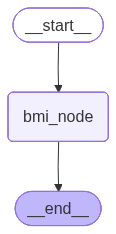

In [8]:
display(Image(workflow.get_graph().draw_mermaid_png()))